
## World Happiness Report

#### Project Objective

“This project analyzes global happiness trends using real-world UN data, focusing on data quality issues, missing value handling, and identifying the key socio-economic drivers of happiness across countries.”

## Importing the Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Loading the dataset

In [3]:
df = pd.read_csv(r"C:\Users\kanub\Downloads\world_happiness_report.csv")

## head() ---> returns the top 5 rows

In [4]:
df.head()

,Unnamed: 0,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
0,0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


## tail() ---> returns last 5 rows

In [5]:
df.tail()

,Unnamed: 0,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
1226,1226,Rwanda*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
1227,1227,Zimbabwe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
1228,1228,Lebanon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
1229,1229,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
1230,1230,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022


## Info () --> Get the basics info about data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     1231 non-null   int64  
 1   Country                        617 non-null    object 
 2   Region                         315 non-null    object 
 3   Happiness Rank                 315 non-null    float64
 4   Happiness Score                315 non-null    float64
 5   Standard Error                 158 non-null    float64
 6   Economy (GDP per Capita)       315 non-null    float64
 7   Family                         470 non-null    float64
 8   Health (Life Expectancy)       315 non-null    float64
 9   Freedom                        470 non-null    float64
 10  Trust (Government Corruption)  315 non-null    float64
 11  Generosity                     1084 non-null   float64
 12  Dystopia Residual              315 non-null    f

## shape ---> Gives the shape of the data(no of rows,no of columns)

In [7]:
df.shape

(1231, 14)

## describe() --->descriptive summary of the dataset

In [8]:
df.describe()

,Unnamed: 0,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
count,1231.000000,315.000000,315.000000,158.000000,315.000000,470.000000,315.000000,470.000000,315.000000,1084.000000,315.000000,1231.000000
mean,615.000000,79.238095,5.378949,0.047885,0.899837,0.990347,0.594054,0.402828,0.140532,0.153545,2.212032,2018.450041
std,355.503399,45.538922,1.141531,0.017146,0.410780,0.318707,0.240790,0.150356,0.115490,0.167592,0.558728,2.284034
min,0.000000,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,-0.300907,0.328580,2015.000000
25%,307.500000,40.000000,4.510000,0.037268,0.594900,0.793000,0.419645,0.297615,0.061315,0.064828,1.884135,2016.000000
50%,615.000000,79.000000,5.286000,0.043940,0.973060,1.025665,0.640450,0.418347,0.106130,0.162140,2.211260,2018.000000
75%,922.500000,118.500000,6.269000,0.052300,1.229000,1.228745,0.787640,0.516850,0.178610,0.252000,2.563470,2020.000000
max,1230.000000,158.000000,7.587000,0.136930,1.824270,1.610574,1.025250,0.669730,0.551910,0.838075,3.837720,2022.000000


## List down all the columns names

In [9]:
df.columns

Index(['Unnamed: 0', 'Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual', 'year'],
      dtype='object')

## isnull() ---> shows the null values 

In [10]:
df.isnull().sum()

Unnamed: 0                          0
Country                           614
Region                            916
Happiness Rank                    916
Happiness Score                   916
Standard Error                   1073
Economy (GDP per Capita)          916
Family                            761
Health (Life Expectancy)          916
Freedom                           761
Trust (Government Corruption)     916
Generosity                        147
Dystopia Residual                 916
year                                0
dtype: int64

## Handling the Missing values

## Converting the column names into lower case values

In [11]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [12]:
df.head(2)

,unnamed:_0,country,region,happiness_rank,happiness_score,standard_error,economy_(gdp_per_capita),family,health_(life_expectancy),freedom,trust_(government_corruption),generosity,dystopia_residual,year
0,0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015


In [13]:
df.drop('unnamed:_0',axis=1,inplace=True)

In [14]:
df.head(2)

,country,region,happiness_rank,happiness_score,standard_error,economy_(gdp_per_capita),family,health_(life_expectancy),freedom,trust_(government_corruption),generosity,dystopia_residual,year
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015


In [15]:
df.drop('standard_error',axis=1,inplace=True)

## Imputation for Missing values

## Mode Imputation Technqiue--Categorical values

In [17]:
mode_country = df['country'].mode()[0]
df['country'].fillna(mode_country, inplace=True)

In [19]:
mode_region = df['region'].mode()[0]
df['region'].fillna(mode_region, inplace = True)

## Median Imputation technique --- Numerical values

In [20]:
df['happiness_rank'] = df['happiness_rank'].fillna(df['happiness_rank'].median())
df['happiness_rank'].median()

np.float64(79.0)

In [21]:
df['economy_(gdp_per_capita)'] = df['economy_(gdp_per_capita)'].fillna(df['economy_(gdp_per_capita)'].median())
df['economy_(gdp_per_capita)'].median()

np.float64(0.97306)

In [22]:
df['family'] = df['family'].fillna(df['family'].median())
df['family'].median()

np.float64(1.025665)

In [23]:
df['health_(life_expectancy)'] = df['health_(life_expectancy)'].fillna(df['health_(life_expectancy)'].median())
df['health_(life_expectancy)'].median()

np.float64(0.64045)

In [24]:
df['freedom'] = df['freedom'].fillna(df['freedom'].median())
df['freedom'].median()

np.float64(0.41834653899999996)

In [25]:
df['trust_(government_corruption)'] = df['trust_(government_corruption)'].fillna(df['trust_(government_corruption)'].median())
df['trust_(government_corruption)'].median()

np.float64(0.10613)

In [26]:
df['generosity'] = df['generosity'].fillna(df['generosity'].median())
df['generosity'].median()

np.float64(0.16214)

In [27]:
df['dystopia_residual'] = df['dystopia_residual'].fillna(df['dystopia_residual'].median())
df['dystopia_residual'].median()

np.float64(2.21126)

## Mean Imputation Technique

In [28]:
df['happiness_score'] = df['happiness_score'].fillna(df['happiness_score'].mean())
df['happiness_score'].mean()

np.float64(5.378949206349205)

In [29]:
df.isnull().sum()

country                          0
region                           0
happiness_rank                   0
happiness_score                  0
economy_(gdp_per_capita)         0
family                           0
health_(life_expectancy)         0
freedom                          0
trust_(government_corruption)    0
generosity                       0
dystopia_residual                0
year                             0
dtype: int64

## Encoding 

In [30]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
encoder = LabelEncoder()

df['country'] = encoder.fit_transform(df['country'])
df['region'] = encoder.fit_transform(df['region'])

In [33]:
df.head(2)

,country,region,happiness_rank,happiness_score,economy_(gdp_per_capita),family,health_(life_expectancy),freedom,trust_(government_corruption),generosity,dystopia_residual,year
0,165,9,1.0,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,71,9,2.0,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015


## data Correlation

In [34]:
df.corr()

,country,region,happiness_rank,happiness_score,economy_(gdp_per_capita),family,health_(life_expectancy),freedom,trust_(government_corruption),generosity,dystopia_residual,year
country,1.000000,-0.284173,-0.028201,0.026414,-0.057922,0.009648,-0.065795,-0.003256,0.151385,0.371534,-0.017427,-0.346147
region,-0.284173,1.000000,0.160595,-0.140474,-0.091913,0.137421,-0.148188,0.115109,-0.024944,-0.121577,-0.068517,0.487059
happiness_rank,-0.028201,0.160595,1.000000,-0.993895,-0.774800,-0.505026,-0.731855,-0.446261,-0.365778,-0.062331,-0.522135,-0.004049
happiness_score,0.026414,-0.140474,-0.993895,1.000000,0.770092,0.508594,0.724520,0.454772,0.385428,0.070314,0.526343,0.000313
economy_(gdp_per_capita),-0.057922,-0.091913,-0.774800,0.770092,1.000000,0.464462,0.794316,0.279493,0.244285,-0.054838,0.078304,0.129780
family,0.009648,0.137421,-0.505026,0.508594,0.464462,1.000000,0.470567,0.429412,0.057154,-0.001152,0.038636,0.128726
health_(life_expectancy),-0.065795,-0.148188,-0.731855,0.724520,0.794316,0.470567,1.000000,0.311097,0.197678,-0.016026,0.024709,0.107986
freedom,-0.003256,0.115109,-0.446261,0.454772,0.279493,0.429412,0.311097,1.000000,0.370465,0.141272,0.028373,0.056425
trust_(government_corruption),0.151385,-0.024944,-0.365778,0.385428,0.244285,0.057154,0.197678,0.370465,1.000000,0.196531,-0.022465,-0.191655
generosity,0.371534,-0.121577,-0.062331,0.070314,-0.054838,-0.001152,-0.016026,0.141272,0.196531,1.000000,-0.045848,-0.451749


## Visualization using seaborn and matplotlib

## Heat Map

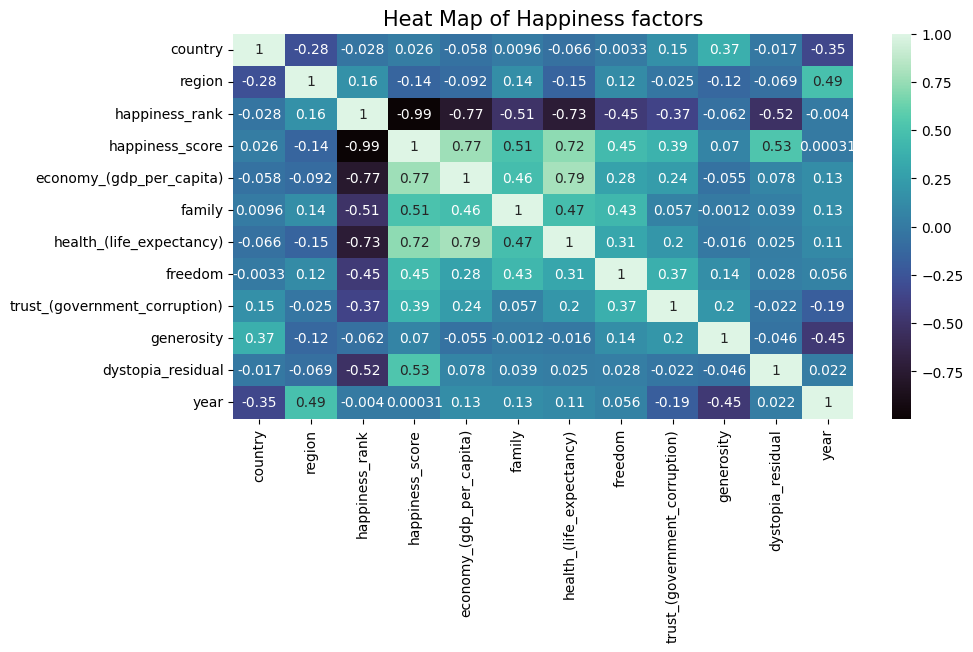

In [35]:
plt.figure(figsize =(10,5))
sns.heatmap(df.corr(),annot=True,cmap = 'mako')
plt.title("Heat Map of Happiness factors",fontsize=15)
plt.show()

## Distribution of Happiness Score

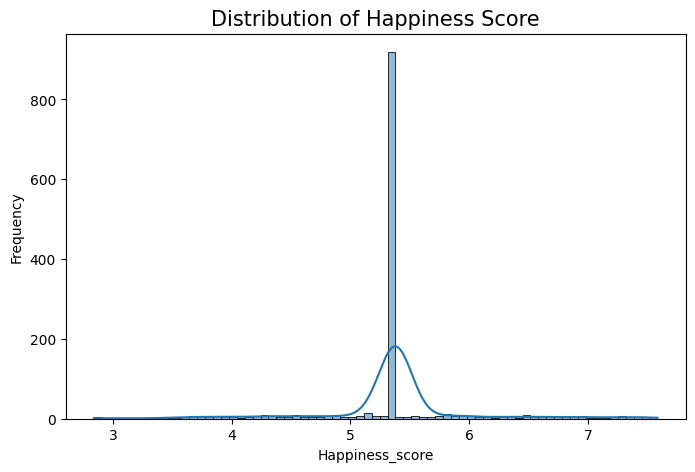

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['happiness_score'],kde=True)
plt.title("Distribution of Happiness Score",fontsize=15)
plt.xlabel("Happiness_score")
plt.ylabel("Frequency")
plt.show()

## Scatter plot of Economy vs Happiness_score 

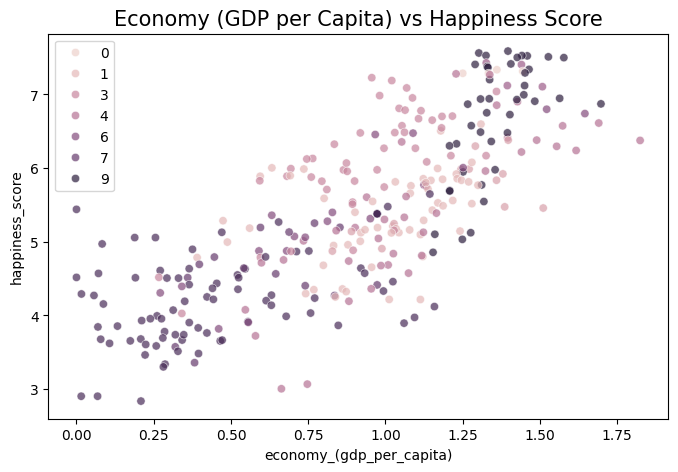

In [37]:
plt.figure(figsize = (8,5))
sns.scatterplot(df,x ='economy_(gdp_per_capita)', y ='happiness_score',hue ='region',alpha = 0.7)
plt.title('Economy (GDP per Capita) vs Happiness Score', fontsize=15)
plt.legend()
plt.show()

## Happiness Score Trend over Years

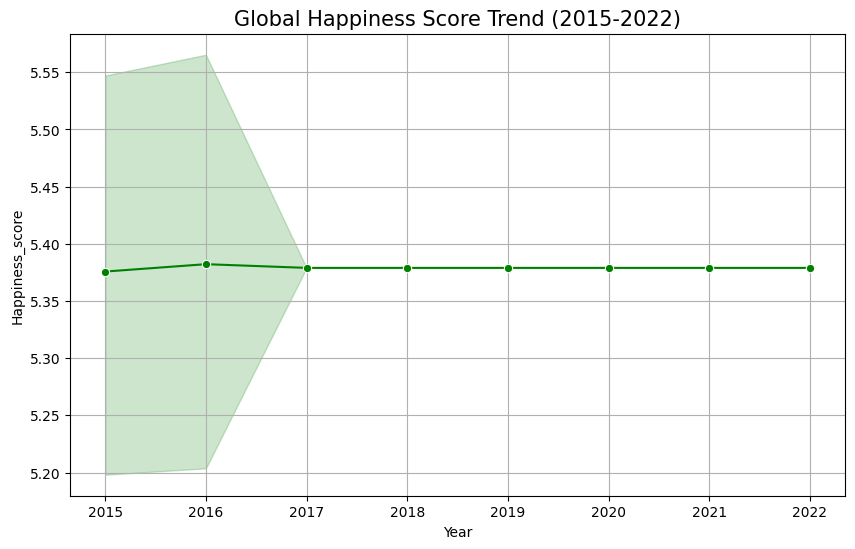

In [38]:
plt.figure(figsize=(10, 6))
sns.lineplot(df, x='year', y='happiness_score', marker='o', color='green')
plt.title('Global Happiness Score Trend (2015-2022)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Happiness_score')
plt.grid(True)
plt.show()

## PairPlot

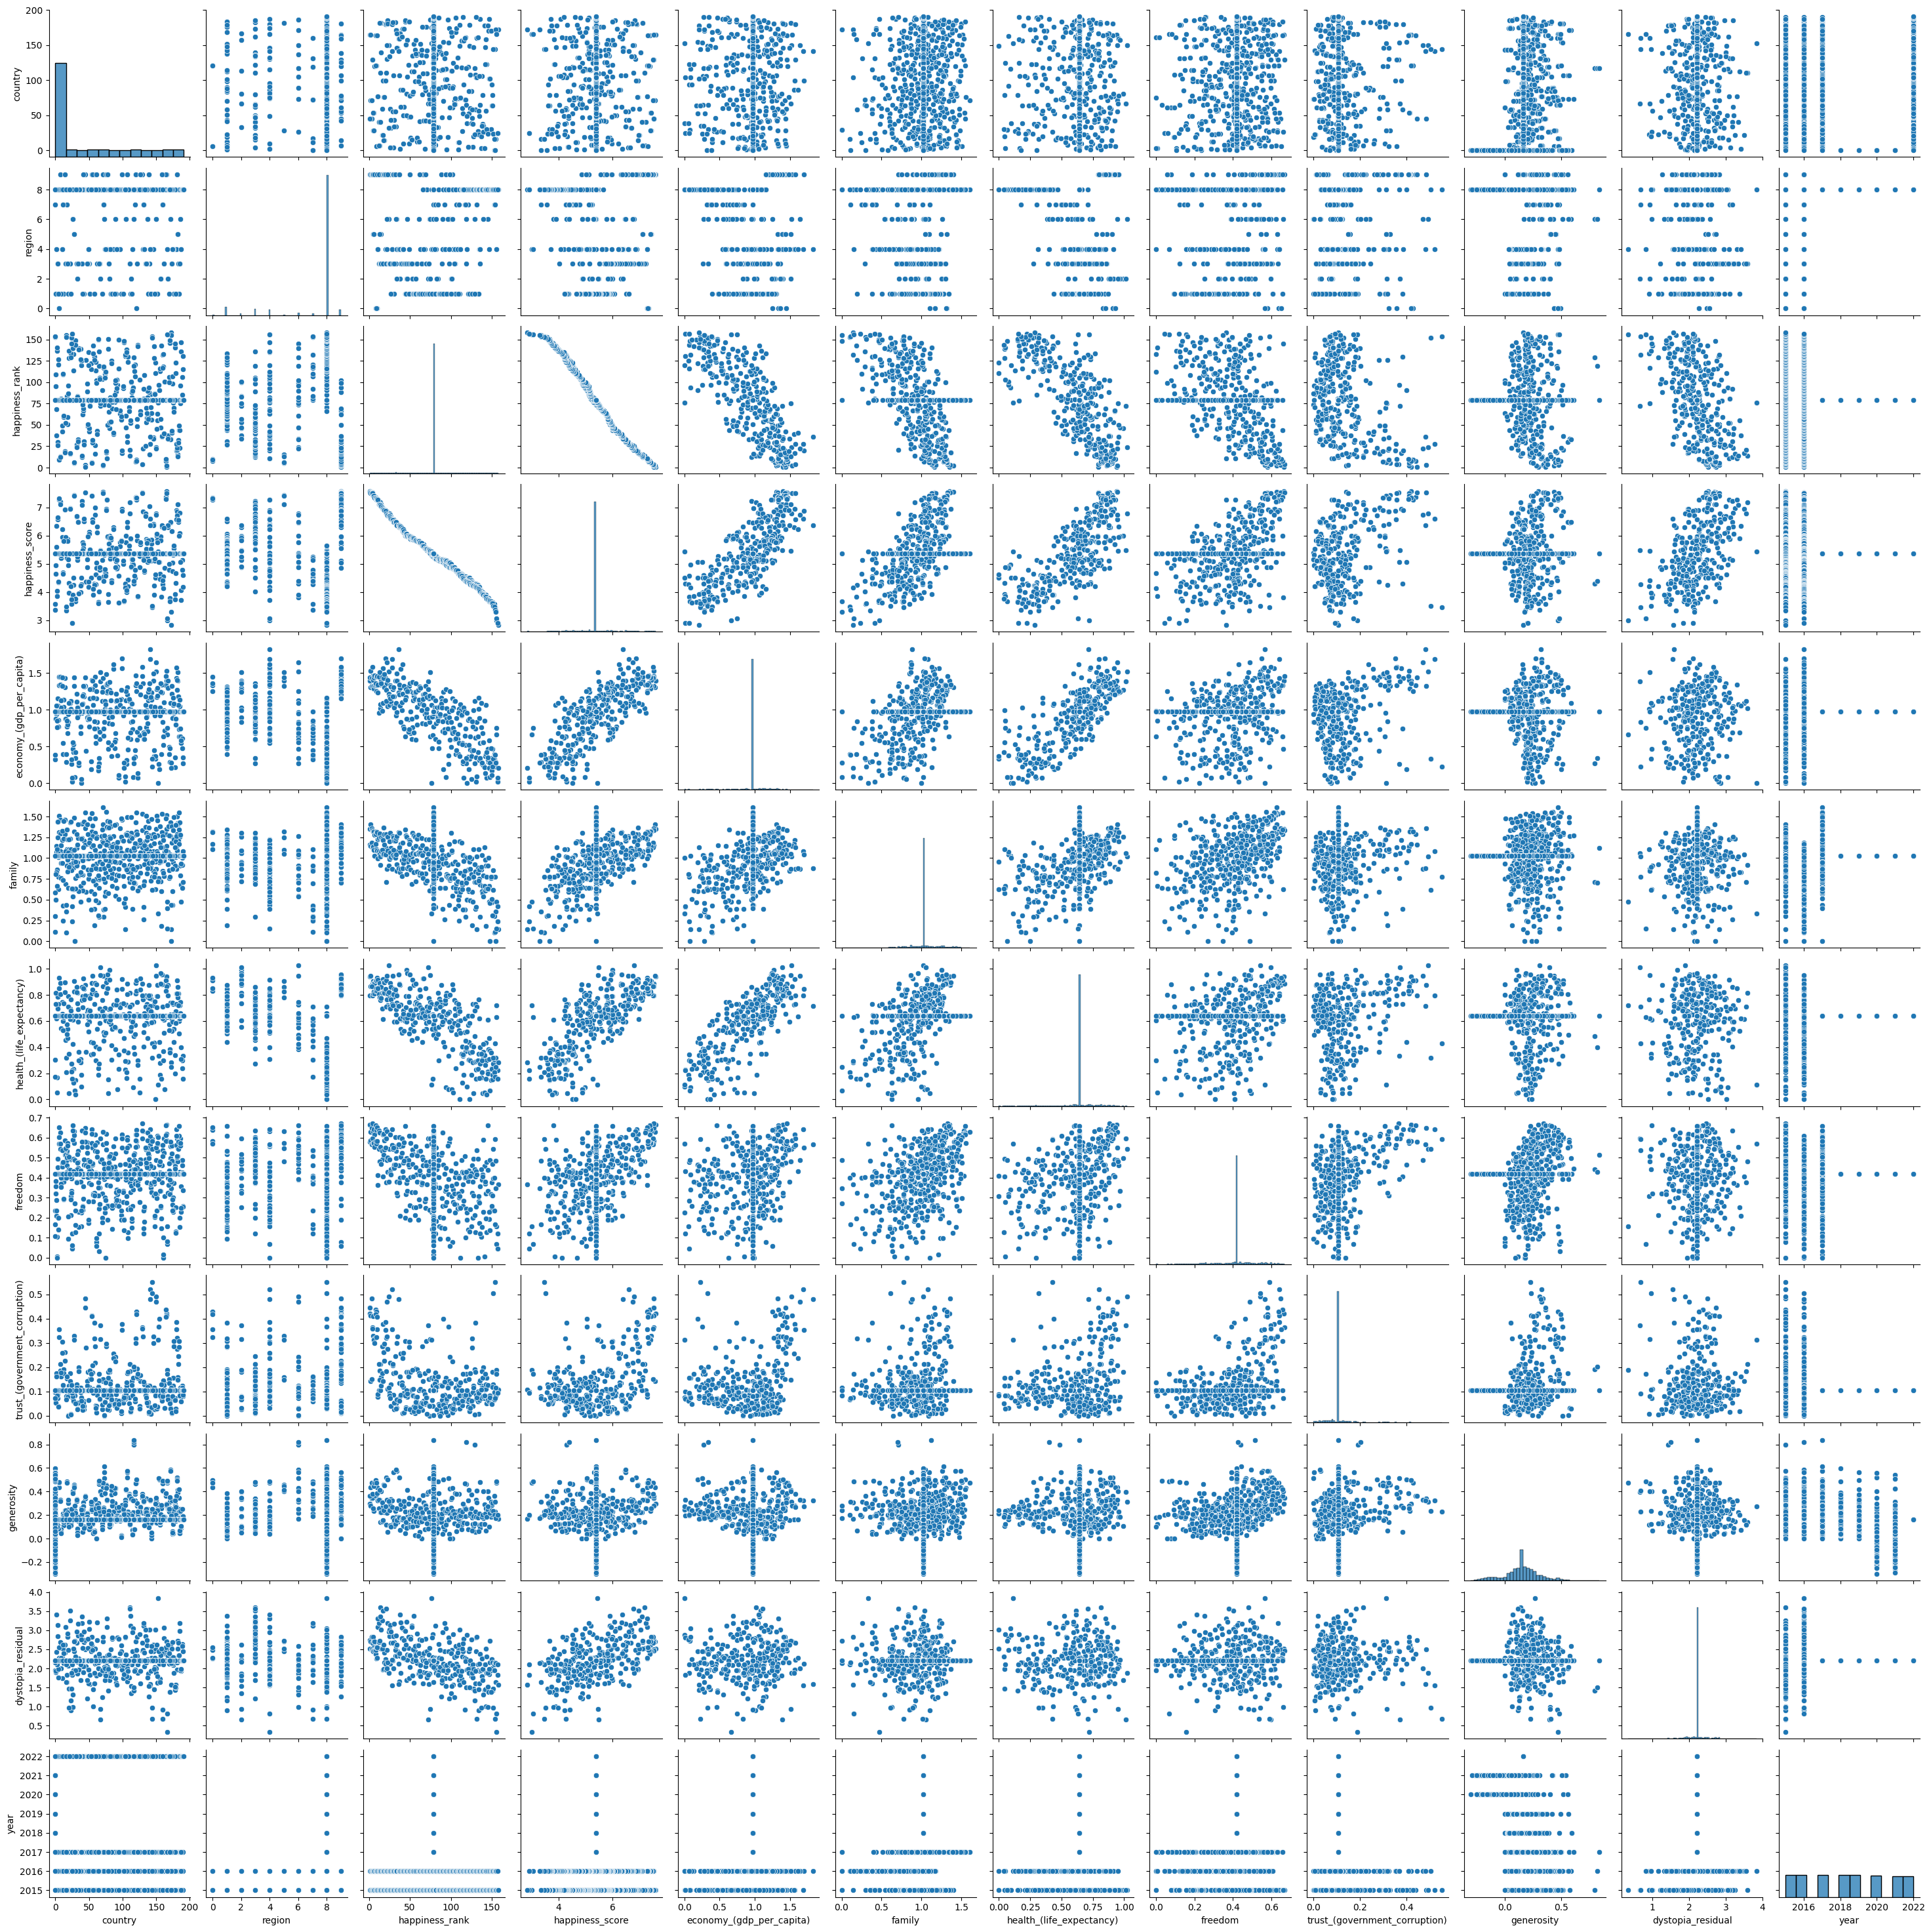

In [40]:
sns.pairplot(df)
plt.show()

Text(0.5, 1.0, 'Average Happiness Score by Region')

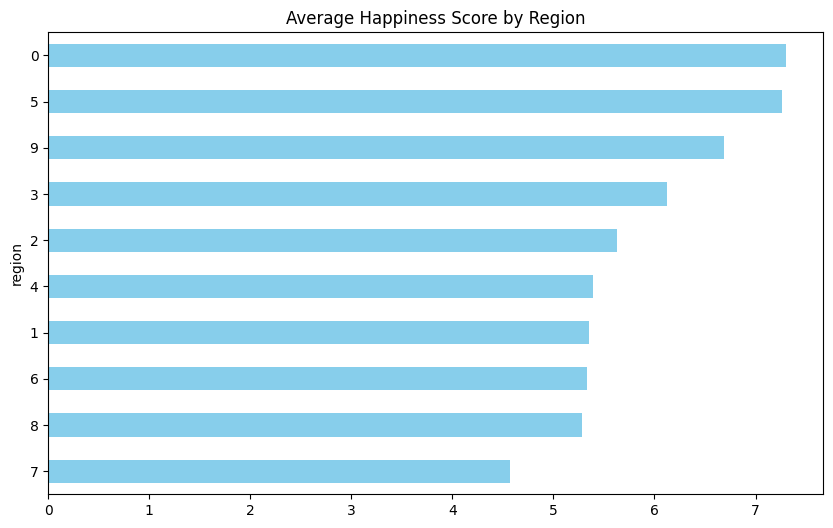

In [42]:
plt.figure(figsize=(10, 6))
region_avg = df.groupby('region')['happiness_score'].mean().sort_values()
region_avg.plot(kind='barh', color='skyblue')
plt.title('Average Happiness Score by Region')
